<a href="https://colab.research.google.com/github/mercia-loko/Elections-municipales-2026/blob/main/Analyse_elections_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyse des élections municipales 2026
Auteure : Mercia Loko

Source : data.gouv.fr

## Objectif
Analyser la parité, les âges et les nuances politiques des élus au 1er tour 2026 à Paris et Lyon.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount ('/content/drive')

Mounted at /content/drive


In [8]:
import pandas as pd
from google.colab import drive

df = pd.read_csv ('/content/drive/MyDrive/conseils-darrondissement-paris-lyon-marseille-2026-candidats-elus-tour-1-2026-03-16.csv', sep= ';')
df['DATNAIPSN'] = pd.to_datetime(df['DATNAIPSN'])
df['AGE'] = 2026 - df['DATNAIPSN'].dt.year
villes = {'69': 'Lyon', '75': 'Paris'}
df['VILLE'] = df['CODDPT'].astype(str).map(villes)
print(df.shape)
df.head()

(134, 14)


,NOMPSN,PREPSN,DATNAIPSN,SEXPSN,CODPRO,EFFECTIF_LEGAL,CODDPT,CODCOM,CODSECT,CODE_NUANCE_DE_LISTE,CODE_PERSONNALITE,TOUR_ELECTION,AGE,VILLE
0,RUDIGOZ,Thomas,1971-01-11,M,31,20,69,69123,69123SR05,LDVC,NaN,élu T1,55,Lyon
1,MARANO,Gabrielle,1998-06-18,F,52,20,69,69123,69123SR05,LDVC,NaN,élu T1,28,Lyon
2,AURIA,Frédéric,1971-01-08,M,34,20,69,69123,69123SR05,LDVC,NaN,élu T1,55,Lyon
3,HAZENE GUILLERMIN,Dabia,1964-06-19,F,31,20,69,69123,69123SR05,LDVC,NaN,élu T1,62,Lyon
4,CIAMPI,Lucas,2003-09-25,M,84,20,69,69123,69123SR05,LDVC,NaN,élu T1,23,Lyon


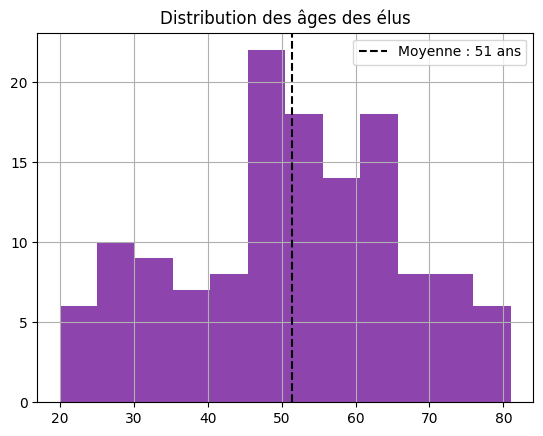

In [ ]:
##Distribution des âges

df['AGE'].hist(bins=12, color='#8e44ad')
plt.axvline(df['AGE'].mean(), color='black', linestyle='--', label=f'Moyenne : {df['AGE'].mean():.0f} ans')
plt.title('Distribution des âges des élus')
plt.legend()
plt.savefig('ages.png')
plt.show()

In [ ]:
#### Observations
#L'âge moyen des élus est de 51 ans. La tranche 45-60 ans est largement dominante. Les moins de 30 ans sont très peu représentés malgré quelques cas notables, ce qui soulève la question du renouvellement générationnel en politique locale.


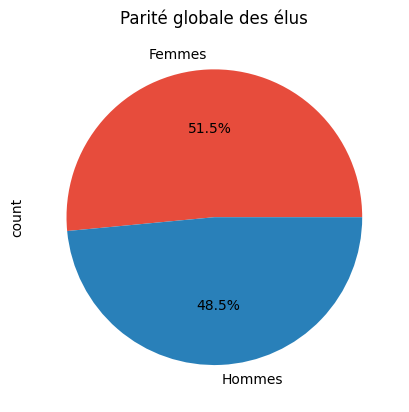

In [ ]:
#Analyse de la parité

parite = df['SEXPSN'].value_counts()
parite.plot(kind='pie', labels=['Femmes','Hommes'],
            autopct='%1.1f%%', colors=['#e74c3c','#2980b9'])
plt.title('Parité globale des élus')
plt.savefig('parite.png')
plt.show()

In [ ]:
#### Observations
#Sur l'ensemble des élus au 1er tour, on observe une répartition quasi équilibrée entre femmes et hommes.
#Cela reflète l'effet de la loi sur la parité de 2000 qui impose l'alternance homme/femme sur les listes.


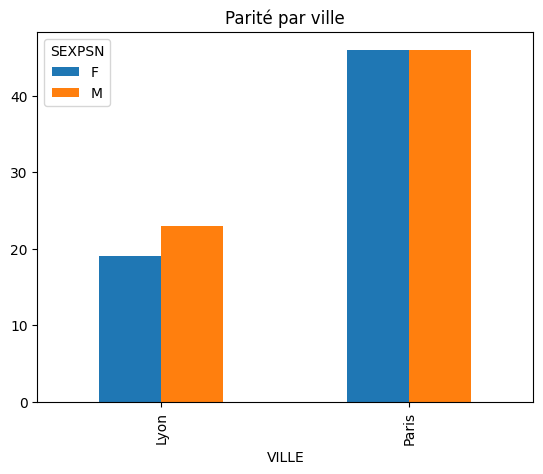

In [ ]:
## Parité par villes

df.groupby(['VILLE','SEXPSN']).size().unstack().plot(kind='bar')
plt.title('Parité par ville')
plt.savefig('parite_ville.png')
plt.show()


In [ ]:
#### Observations
#La parité varie selon les villes. Certaines nuances politiques respectent mieux l'équilibre que d'autres.
#Cela montre que la loi garantit la parité sur les listes mais pas nécessairement parmi les élus finaux, selon le nombre de sièges obtenus par liste.


In [ ]:
## Conclusions

#La parité progresse mais reste inégale selon les villes : les résultats varient de plusieurs points selon les territoires, montrant que la loi Jospin seule ne suffit pas.
#La classe politique locale reste senior : peu de jeunes élus malgré quelques candidats de moins de 25 ans.
#Des dynamiques politiques très locales : les nuances dominantes diffèrent fortement entre Paris et Lyon, reflétant des identités électorales distinctes.